In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Importing the required data 
history_data = pd.read_csv('recent_history_with_rankings.csv')
history_data.columns

Index(['year', 'Stage Name', 'Home Team Name', 'Home Team Code',
       'Away Team Name', 'Away Team Code', 'Home Team Score',
       'Away Team Score', 'Result', 'Home Team Win', 'Away Team Win', 'Draw',
       'rank_home', 'total.points_home', 'previous.points_home',
       'diff.points_home', 'rank_away', 'total.points_away',
       'previous.points_away', 'diff.points_away', 'rank_diff', 'points_diff',
       'total_goals', 'rank_home_group'],
      dtype='str')

In [3]:
columns_needed = ['year', 'Stage Name', 'Home Team Name','rank_home', 'Away Team Name','rank_away', 'Home Team Score',
                  'Away Team Score', 'total_goals','rank_diff', 'points_diff', 'Result', 'total.points_home', 'total.points_away']
data = history_data[columns_needed]
data

,year,Stage Name,Home Team Name,rank_home,Away Team Name,rank_away,Home Team Score,Away Team Score,total_goals,rank_diff,points_diff,Result,total.points_home,total.points_away
0,2022,final,Argentina,2.0,France,3.0,3,3,6,-1.0,14.99,home team win,1838.38,1823.39
1,2022,third-place match,Croatia,7.0,Morocco,11.0,2,1,3,-4.0,55.27,home team win,1727.62,1672.35
2,2022,group stage,South Korea,25.0,Portugal,9.0,2,1,3,16.0,-163.05,home team win,1539.49,1702.54
3,2022,group stage,Ghana,58.0,Uruguay,16.0,0,2,2,42.0,-227.43,away team win,1400.02,1627.45
4,2022,group stage,Japan,20.0,Spain,10.0,2,1,3,10.0,-99.63,home team win,1593.08,1692.71
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,1994,group stage,Brazil,1.0,Sweden,3.0,1,1,2,-2.0,6.00,draw,67.00,61.00
496,1994,group stage,Belgium,24.0,Saudi Arabia,27.0,0,1,1,-3.0,2.00,away team win,47.00,45.00
497,1994,group stage,Morocco,32.0,Netherlands,6.0,1,2,3,26.0,-17.00,away team win,43.00,60.00
498,1994,group stage,Spain,2.0,South Korea,34.0,2,2,4,-32.0,21.00,draw,62.00,41.00


C:\Users\HomePC\AppData\Local\Temp\ipykernel_7788\2339061502.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='Stage Name', y='rank_diff', palette='viridis')


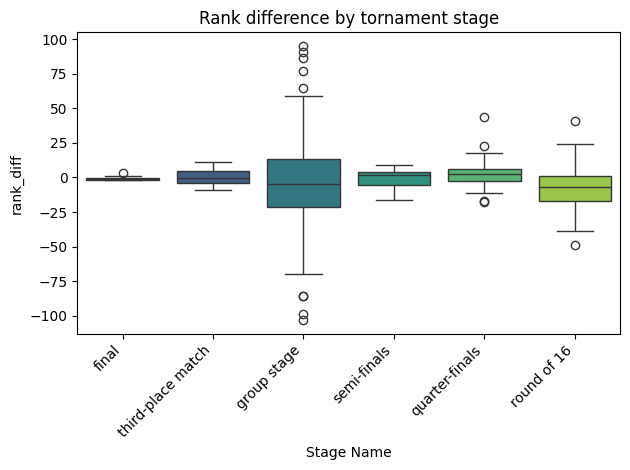

In [4]:
#How is the rank gap affects each stage of the tornament
sns.boxplot(data=data, x='Stage Name', y='rank_diff', palette='viridis')
plt.title('Rank difference by tornament stage', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [5]:
#favourite
data['favourite'] = 'Draw'
data.loc[data['rank_home'] < data['rank_away'], 'favourite'] = 'Home Team'
data.loc[data['rank_home'] > data['rank_away'], 'favourite'] = 'Away Team'
data

,year,Stage Name,Home Team Name,rank_home,Away Team Name,rank_away,Home Team Score,Away Team Score,total_goals,rank_diff,points_diff,Result,total.points_home,total.points_away,favourite
0,2022,final,Argentina,2.0,France,3.0,3,3,6,-1.0,14.99,home team win,1838.38,1823.39,Home Team
1,2022,third-place match,Croatia,7.0,Morocco,11.0,2,1,3,-4.0,55.27,home team win,1727.62,1672.35,Home Team
2,2022,group stage,South Korea,25.0,Portugal,9.0,2,1,3,16.0,-163.05,home team win,1539.49,1702.54,Away Team
3,2022,group stage,Ghana,58.0,Uruguay,16.0,0,2,2,42.0,-227.43,away team win,1400.02,1627.45,Away Team
4,2022,group stage,Japan,20.0,Spain,10.0,2,1,3,10.0,-99.63,home team win,1593.08,1692.71,Away Team
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,1994,group stage,Brazil,1.0,Sweden,3.0,1,1,2,-2.0,6.00,draw,67.00,61.00,Home Team
496,1994,group stage,Belgium,24.0,Saudi Arabia,27.0,0,1,1,-3.0,2.00,away team win,47.00,45.00,Home Team
497,1994,group stage,Morocco,32.0,Netherlands,6.0,1,2,3,26.0,-17.00,away team win,43.00,60.00,Away Team
498,1994,group stage,Spain,2.0,South Korea,34.0,2,2,4,-32.0,21.00,draw,62.00,41.00,Home Team


In [6]:
win_rate = data[data['favourite'] == 'Home Team']['Result'].value_counts(normalize=True)*100
win_rate

Result
home team win    67.241379
draw             19.310345
away team win    13.448276
Name: proportion, dtype: float64

C:\Users\HomePC\AppData\Local\Temp\ipykernel_7788\1283318353.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=win_rate.index, y=win_rate.values, palette='viridis')


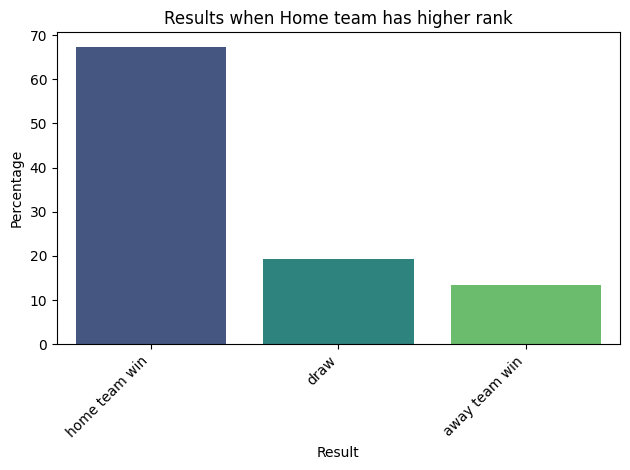

In [7]:
# Seeing if higher rank results to higher win for home teams
sns.barplot(x=win_rate.index, y=win_rate.values, palette='viridis')
plt.title('Results when Home team has higher rank')
plt.ylabel('Percentage')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

(np.float64(-1.0999997240721284),
 np.float64(1.0999971368312749),
 np.float64(-1.0999991526787622),
 np.float64(1.0999954689327969))

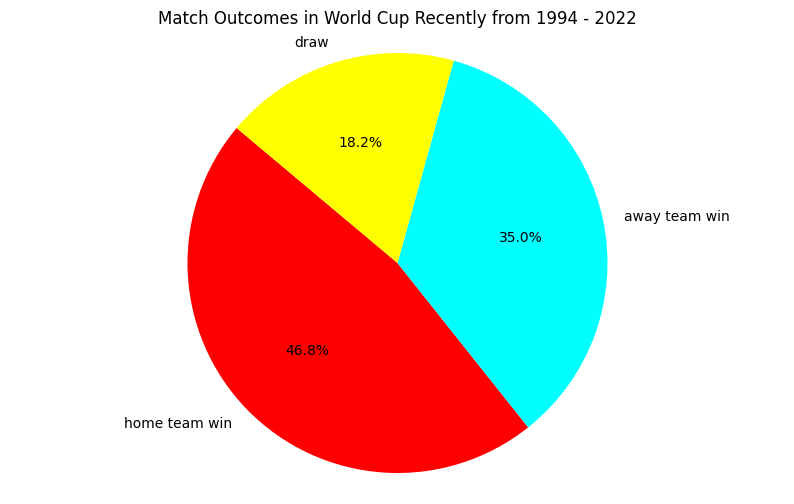

In [8]:
plt.figure(figsize=(10,6))
colors = ['red', 'aqua', 'yellow']

data['Result'].value_counts(normalize=True).plot.pie(autopct='%.1f%%', colors=colors, startangle=140)
plt.title('Match Outcomes in World Cup Recently from 1994 - 2022')
plt.axis('equal')

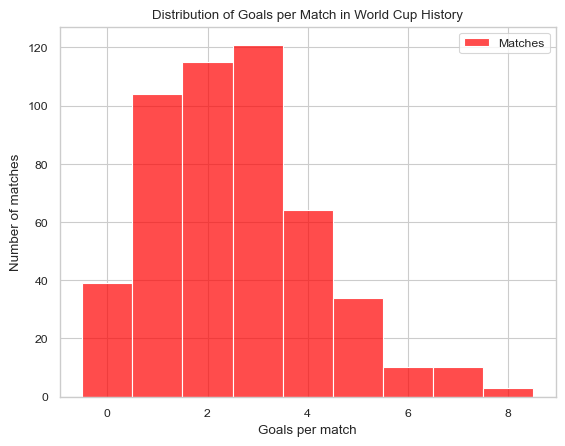

In [9]:
# Goal distribution
plt.figure()
sns.set_theme(context='paper', style='whitegrid')
sns.histplot(data=data, x='total_goals', discrete=True, color='red', alpha=0.7, label='Matches')
plt.xlabel('Goals per match')
plt.ylabel('Number of matches')
plt.title('Distribution of Goals per Match in World Cup History')
plt.legend()
plt.show()

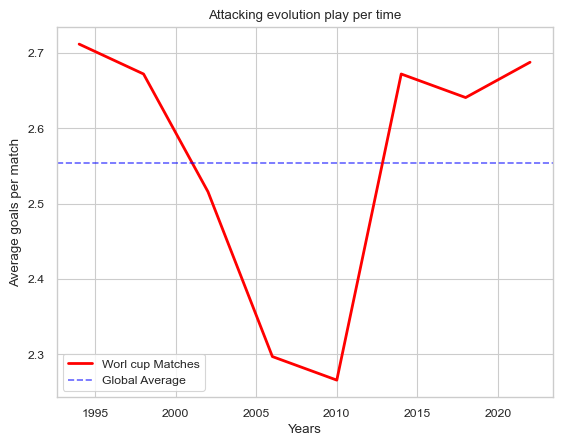

In [10]:
# Attacking revolution
avg_goals_year = data.groupby('year')['total_goals'].mean()

plt.figure()
sns.set_theme(context='paper', style='whitegrid')
sns.lineplot(x=avg_goals_year.index, y=avg_goals_year.values, label = 'Worl cup Matches', color = 'red', linewidth=2)
plt.axhline(y=data['total_goals'].mean(), linestyle = '--', color = 'blue', alpha = 0.6, label = 'Global Average')
plt.xlabel('Years')
plt.ylabel('Average goals per match')
plt.title('Attacking evolution play per time')
plt.legend()
plt.show()

C:\Users\HomePC\AppData\Local\Temp\ipykernel_7788\3565734033.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top10.values, y=top10.index, palette='Reds_r')


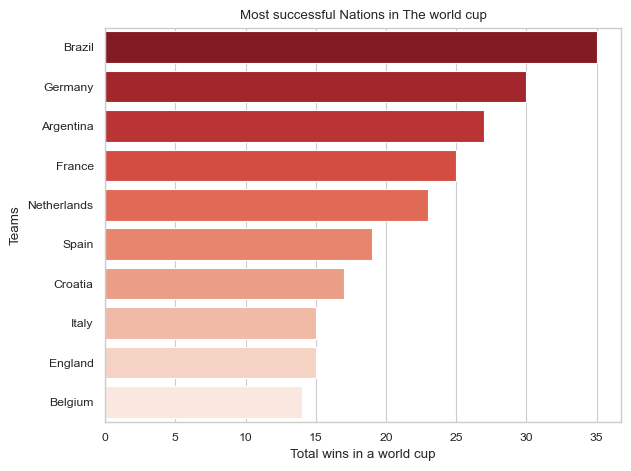

In [11]:
def get_wins(team):
    home =data[(data['Home Team Name'] == team) & (data['Result'] == 'home team win')].shape[0]
    away = data[(data['Away Team Name'] == team) & (data['Result'] == 'away team win')].shape[0]
    return home + away

top_teams = data['Home Team Name'].unique()
records = {team:get_wins(team) for team in top_teams}
top10 = pd.Series(records).sort_values(ascending=False).head(10)

sns.set_theme(context='paper', style='whitegrid')
sns.barplot(x=top10.values, y=top10.index, palette='Reds_r')
plt.xlabel('Total wins in a world cup')
plt.ylabel('Teams')
plt.title('Most successful Nations in The world cup')
plt.tight_layout()
plt.show()

In [12]:
data.to_csv('Clean_data.csv', index=False)
print('Data is created')

Data is created
